# Following the money: graph analytics inside Vertica

A payments network of 50,000 accounts, stored as an ordinary Vertica table. One account is flagged.
This notebook asks the questions an investigator asks, and every answer is one SQL statement that
calls a function of the `vgraph` library (https://github.com/mogomo/vertica-graph-udx):

| Step | Question | Function |
|---|---|---|
| 2 | Where did the flagged account's money go, up to five transfers on? | `gkhop` |
| 3 | How is the flagged account connected to a given customer? | `gpath` |
| 4 | Which groups of accounts only transact among themselves? | `gcomponents` |
| 5 | Which accounts are the hubs of the money flow? | `gpagerank` |
| 6 | Which accounts look unusual? Graph features into in-database machine learning | VerticaPy |
| 7 | A transfer arrives. Do the answers change without rebuilding anything? | the journal |
| 8 | How far does this go? One billion edges | `gkhop_count` |
| 9 | Measurements | |

**Needs:** a Vertica database with `vgraph` installed (`make deploy`), and Python with
`verticapy`, `vertica-python`, `networkx`, `matplotlib`, `pandas`.
The connection is read from the environment variables `VSQL_HOST`, `VSQL_PORT`, `VSQL_USER`,
`VSQL_PASSWORD`, `VSQL_DATABASE`, the same ones the repository's scripts use. Nothing is stored in the notebook.

In [1]:
import os, time, json, warnings
import pandas as pd, networkx as nx, matplotlib.pyplot as plt, matplotlib as mpl
import vertica_python, verticapy as vp
warnings.filterwarnings("ignore")

conn = vertica_python.connect(
    host=os.environ.get("VSQL_HOST", "127.0.0.1"), port=int(os.environ.get("VSQL_PORT", 5433)),
    user=os.environ.get("VSQL_USER", "dbadmin"), password=os.environ.get("VSQL_PASSWORD", ""),
    database=os.environ.get("VSQL_DATABASE", ""), autocommit=True)
vp.set_connection(conn)

def run(sql):
    # statements without a result
    cur = conn.cursor()
    for stmt in [s for s in sql.split(";\n") if s.strip()]:
        cur.execute(stmt)
        while cur.nextset(): pass

def q(sql):
    # a query into a pandas DataFrame; q.ms = the server time of the statement, from Vertica's own system table
    cur = conn.cursor(); cur.execute(sql); rows = cur.fetchall()
    frame = pd.DataFrame(rows, columns=[c.name for c in cur.description])
    cur.execute("SELECT request_duration_ms FROM v_monitor.query_requests WHERE session_id = CURRENT_SESSION() "
                "AND request NOT ILIKE '%v_monitor.query_requests%' ORDER BY start_timestamp DESC LIMIT 1")
    q.ms = cur.fetchall()[0][0]
    return frame

# one look for every chart
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e6e5e0", "#fcfcfb"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CRITICAL = "#d03b3b"
HOPS = ["#d03b3b", "#0d366b", "#1c5cab", "#3987e5", "#6da7ec", "#9ec5f4"]        # the flagged account, then 1 to 5 transfers on
mpl.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 130, "font.size": 10, "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left"})
print(q("SELECT vgraph.gversion() OVER()").T)

                                                 0
library_version                              0.1.0
format_version                                   1
build_flags      -O2 -std=c++17 aarch64 g++-11.5.0


## 1. The data: an ordinary table

`accounts` holds the business data. `transfers` is the edge table: who paid whom. It is a journal:
rows are only inserted, the database stamps each row with the time it was written (`ts`), and a
reversal is a row with `del = true`. Three small rings of accounts that only pay each other are planted
in the data, and account 4711 is the flagged one.

In [2]:
N = 50000
run(f'''
DROP SCHEMA IF EXISTS VGRAPH_NB CASCADE;
CREATE SCHEMA VGRAPH_NB;
CREATE TABLE VGRAPH_NB.accounts (id INT NOT NULL PRIMARY KEY, name VARCHAR(40), city VARCHAR(20), kind VARCHAR(10));
CREATE TABLE VGRAPH_NB.transfers (
    src INT NOT NULL, dst INT NOT NULL, del BOOLEAN NOT NULL DEFAULT FALSE, amount FLOAT,
    ts TIMESTAMPTZ NOT NULL DEFAULT CLOCK_TIMESTAMP())
ORDER BY src, dst SEGMENTED BY HASH(src) ALL NODES
PARTITION BY (ts AT TIME ZONE 'UTC')::DATE;
CREATE LOCAL TEMP TABLE nb_n ON COMMIT PRESERVE ROWS AS
    SELECT ROW_NUMBER() OVER() AS id FROM vgraph.probe a CROSS JOIN vgraph.probe b LIMIT {N} KSAFE 0;
INSERT INTO VGRAPH_NB.accounts
SELECT id,
       DECODE(id % 12, 0,'Anna',1,'David',2,'Max',3,'Rita',4,'Dan',5,'Lena',6,'Omar',7,'Julia',8,'Tom',9,'Maya',10,'Noah','Eva')
       || ' ' || DECODE((id // 12) % 10, 0,'Berg',1,'Cohen',2,'Rossi',3,'Novak',4,'Silva',5,'Keller',6,'Haddad',7,'Jansen',8,'Moreau','Lind')
       || ' ' || id,
       DECODE(id % 7, 0,'Berlin',1,'Madrid',2,'Tel Aviv',3,'Paris',4,'Vienna',5,'Milan','Prague'),
       CASE WHEN id <= 40 THEN 'merchant' ELSE 'person' END
FROM nb_n;
-- people pay merchants often and each other sometimes; low ids are the popular ones
INSERT INTO VGRAPH_NB.transfers (src, dst, amount, ts)
SELECT id, 1 + FLOOR(40 * POWER(RANDOM(), 2))::INT, ROUND(5 + 200 * RANDOM(), 2), CLOCK_TIMESTAMP() - INTERVAL '2 days'
FROM nb_n WHERE id > 40 AND id <= {N} - 30;
INSERT INTO VGRAPH_NB.transfers (src, dst, amount, ts)
SELECT id, 41 + FLOOR(({N} - 71) * POWER(RANDOM(), 3))::INT, ROUND(20 + 900 * RANDOM(), 2), CLOCK_TIMESTAMP() - INTERVAL '2 days'
FROM nb_n CROSS JOIN (SELECT 1 AS k UNION ALL SELECT 2) t WHERE id > 40 AND id <= {N} - 30;
-- three planted rings among the last 30 accounts: 6, 9 and 15 accounts that pay in a circle
INSERT INTO VGRAPH_NB.transfers (src, dst, amount, ts)
SELECT id, CASE WHEN id = {N} - 24 THEN {N} - 29 WHEN id = {N} - 15 THEN {N} - 23 WHEN id = {N} THEN {N} - 14 ELSE id + 1 END,
       9900, CLOCK_TIMESTAMP() - INTERVAL '2 days'
FROM nb_n WHERE id > {N} - 30;
COMMIT
''')
q("SELECT COUNT(*) AS transfers, COUNT(DISTINCT src) AS payers, ROUND(SUM(amount)) AS total FROM VGRAPH_NB.transfers")

,transfers,payers,total
0,149820,49960,52538267.0


### Register the table as a graph

Two calls. `register_graph` records which columns are the edge, the delete flag and the version.
`refresh_graph` builds the index (a snapshot in compressed sparse row form), stores it **inside Vertica**
and loads it on every node. From then on every query reads the snapshot *plus* the rows written after it.

In [3]:
try: run("CALL vgraph.unregister_graph('nb')")      # left over from an earlier run
except Exception: pass
t = time.time()
run('''
CALL vgraph.register_graph('nb', 'VGRAPH_NB.transfers', 'src', 'dst', 'del', 'amount', TRUE, 'ts', NULL);
CALL vgraph.refresh_graph('nb')
''')
print(f"registered and built in {time.time() - t:.1f} s")
q("SELECT graph, node_count, edge_count, build_seconds FROM vgraph.manifest WHERE graph = 'nb'")

registered and built in 1.6 s


,graph,node_count,edge_count,build_seconds
0,nb,50000,149768,1.304


## 2. Where did the money go?

`gkhop` is a breadth-first search. `direction='out'` follows the transfers forward: the accounts the flagged
account paid, the accounts those paid, and so on, five transfers deep. It returns rows, so the business data is
one join away, in the same statement.

In [4]:
FLAGGED, DEPTH = 4711, 5
COLS = "start, target, src, dst, del, weight, ver, snapshot_id"
hood = q(f'''
SELECT r.node, r.hops, a.name, a.city, a.kind
FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={FLAGGED}, depth={DEPTH}, direction='out') OVER()
      FROM VGRAPH_NB.nb_delta) r
JOIN VGRAPH_NB.accounts a ON a.id = r.node ORDER BY r.hops, r.node''')
print(f"{len(hood)} accounts reached by the money of account {FLAGGED} within {DEPTH} transfers, answered in {q.ms} ms (server time)")
hood.groupby("hops").size().rename("accounts").to_frame().T

78 accounts reached by the money of account 4711 within 5 transfers, answered in 17 ms (server time)


hops,0,1,2,3,4,5
accounts,1,3,6,11,22,35


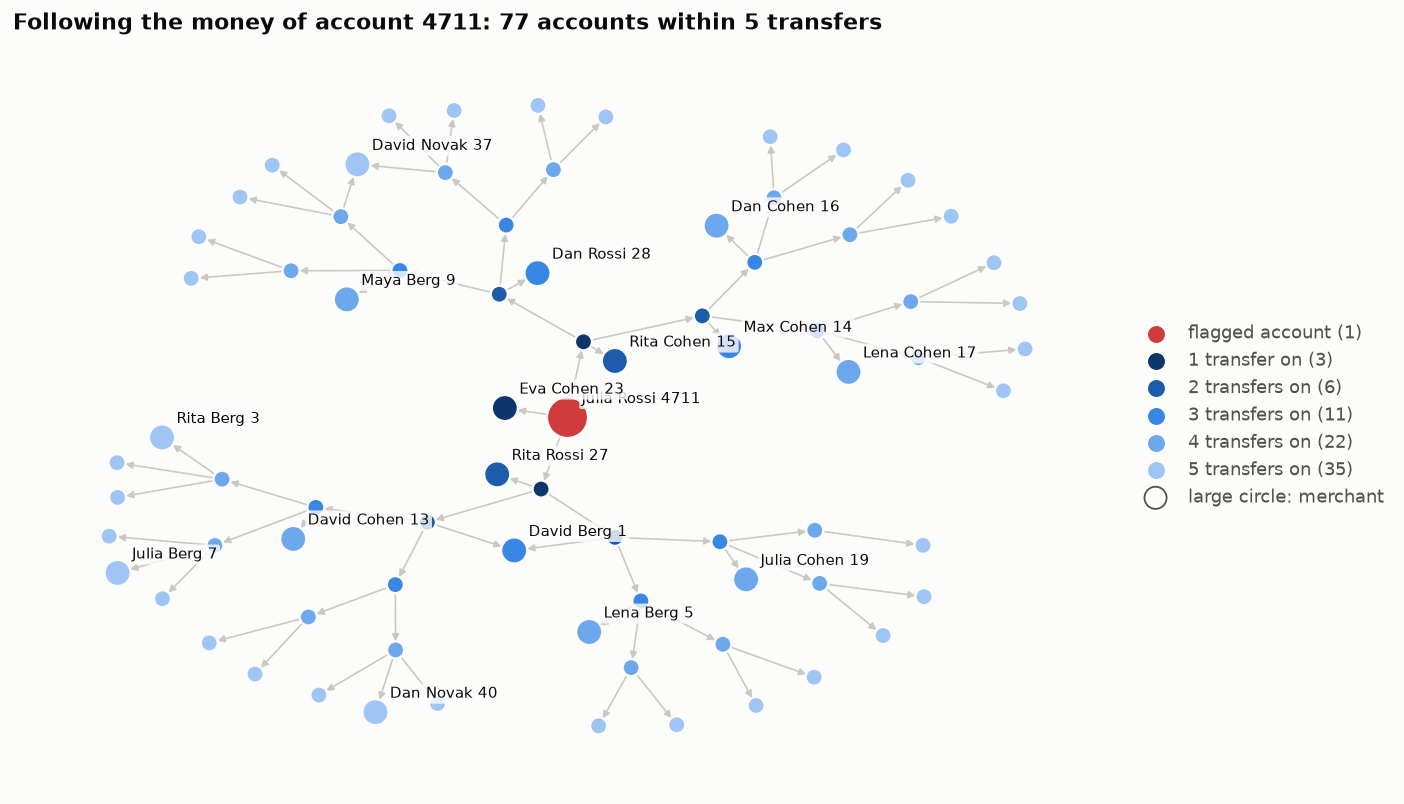

In [5]:
def draw_hood(hood, title, new=(), max_nodes=400):
    # the transfers among the accounts found, as arrows from payer to payee
    keep = hood.sort_values(["hops", "node"]).head(max_nodes)
    ids = ",".join(str(i) for i in keep.node)
    e = q(f"SELECT src, dst FROM VGRAPH_NB.transfers WHERE src IN ({ids}) AND dst IN ({ids}) GROUP BY src, dst HAVING NOT MAX(del)")
    hops = dict(zip(keep.node, keep.hops)); names = dict(zip(keep.node, keep.name)); kinds = dict(zip(keep.node, keep.kind))
    g = nx.DiGraph(); g.add_nodes_from(keep.node)
    g.add_edges_from((a, b) for a, b in zip(e.src, e.dst) if hops[b] == hops[a] + 1 or a in new or b in new)   # the edges the search followed
    pos = nx.kamada_kawai_layout(g.to_undirected())
    fig, ax = plt.subplots(figsize=(11, 7.5)); ax.grid(False); ax.set_axis_off()
    size = {n: 520 if hops[n] == 0 else 210 if kinds[n] == "merchant" else 90 for n in g}
    nx.draw_networkx_edges(g, pos, ax=ax, edge_color="#c9c8c2", width=0.9, arrowsize=8, node_size=[size[n] for n in g])
    if new:
        fresh = [(a, b) for a, b in g.edges if a in new or b in new]
        nx.draw_networkx_edges(g, pos, edgelist=fresh, ax=ax, edge_color=ORANGE, width=2.6, arrowsize=12, node_size=[size[n] for n in g])
    for h in sorted(set(hops.values()), reverse=True):
        nodes = [n for n in g if hops[n] == h]
        nx.draw_networkx_nodes(g, pos, nodelist=nodes, ax=ax, node_color=HOPS[min(h, 5)], edgecolors=SURFACE, linewidths=1.3,
                               node_size=[size[n] for n in nodes])
        ax.scatter([], [], s=70, color=HOPS[min(h, 5)], label=("flagged account" if h == 0 else f"{h} transfer{'s' if h > 1 else ''} on") + f" ({len(nodes)})")
    ax.scatter([], [], s=150, color="none", edgecolors=INK2, label="large circle: merchant")
    for n in g:
        if hops[n] == 0 or n in new or kinds[n] == "merchant":
            ax.annotate(names[n], pos[n], xytext=(8, 8), textcoords="offset points", fontsize=8.5, color=INK,
                        bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.8))
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1][1:] + handles[::-1][:1], labels[::-1][1:] + labels[::-1][:1], loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, labelcolor=INK2)
    ax.set_title(title); plt.show()

draw_hood(hood, f"Following the money of account {FLAGGED}: {len(hood) - 1} accounts within {DEPTH} transfers")

## 3. How is the flagged account connected to a given customer?

`gpath` returns the shortest chain, one row per step. `weighted=true` would follow the smallest
sum of the weight column instead (Dijkstra).

In [6]:
far = q(f'''SELECT MIN(node) AS node FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={FLAGGED}, depth=4, exact=true, direction='both') OVER()
            FROM VGRAPH_NB.nb_delta) r''').node[0]
path = q(f'''
SELECT p.hop_no, p.node, a.name, a.city, a.kind
FROM (SELECT vgraph.gpath({COLS} USING PARAMETERS graph='nb', start={FLAGGED}, target={far}, direction='both') OVER()
      FROM VGRAPH_NB.nb_delta) p JOIN VGRAPH_NB.accounts a ON a.id = p.node ORDER BY p.hop_no''')
print(f"answered in {q.ms} ms (server time)")
path

answered in 15 ms (server time)


,hop_no,node,name,city,kind
0,0,4711,Julia Rossi 4711,Berlin,person
1,1,42,Omar Novak 42,Berlin,person
2,2,9599,Eva Lind 9599,Tel Aviv,person
3,3,7,Julia Berg 7,Berlin,merchant
4,4,77,Lena Haddad 77,Berlin,person


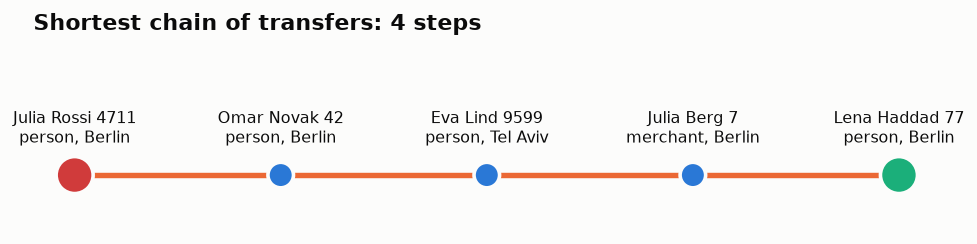

In [7]:
fig, ax = plt.subplots(figsize=(9, 1.9)); ax.grid(False); ax.set_axis_off()
xs = range(len(path))
ax.plot(xs, [0] * len(path), color=ORANGE, lw=3, zorder=1)
ax.scatter(xs, [0] * len(path), s=[420] + [200] * (len(path) - 2) + [420], color=[CRITICAL] + [BLUE] * (len(path) - 2) + [AQUA],
           edgecolors=SURFACE, linewidths=2, zorder=2)
for x, r in zip(xs, path.itertuples()):
    ax.annotate(f"{r.name}\n{r.kind}, {r.city}", (x, 0), xytext=(0, 18), textcoords="offset points", ha="center", fontsize=9, color=INK)
ax.set_ylim(-0.5, 1.2); ax.set_title(f"Shortest chain of transfers: {len(path) - 1} steps"); plt.show()

## 4. Which groups of accounts only transact among themselves?

`gcomponents` labels every account with its connected component. Almost everyone belongs to one giant
component. The small ones are closed circles of accounts, a classic pattern worth a look. `gcomponents_count` returns one row per
component; `gcomponents` returns the component of every account, ready to join.

In [8]:
comp = q(f'''
SELECT component, nodes AS accounts FROM (SELECT vgraph.gcomponents_count({COLS} USING PARAMETERS graph='nb') OVER() FROM VGRAPH_NB.nb_delta) c
ORDER BY nodes DESC''')
print(f"{len(comp)} components, answered in {q.ms} ms (server time)")
comp

4 components, answered in 5 ms (server time)


,component,accounts
0,1,49970
1,49986,15
2,49977,9
3,49971,6


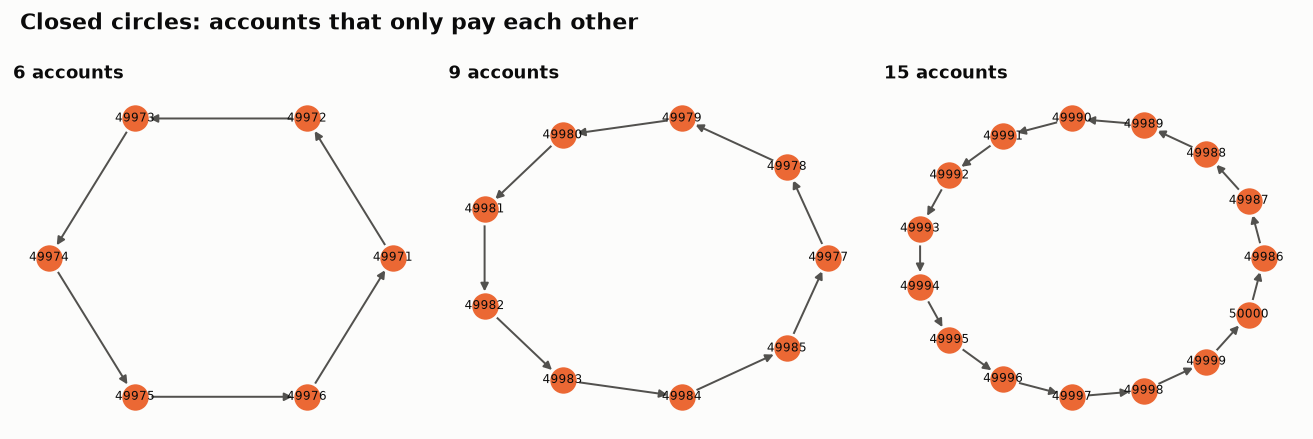

In [9]:
rings = comp[comp.accounts < 100]
members = q(f'''
WITH c AS (SELECT vgraph.gcomponents({COLS} USING PARAMETERS graph='nb') OVER() FROM VGRAPH_NB.nb_delta)
SELECT c.component, t.src, t.dst FROM c JOIN VGRAPH_NB.transfers t ON t.src = c.node
WHERE c.component IN ({",".join(str(c) for c in rings.component)})''')
fig, axes = plt.subplots(1, len(rings), figsize=(3.4 * len(rings), 3.4))
for ax, (cid, grp) in zip(axes, members.groupby("component")):
    g = nx.DiGraph(); g.add_edges_from(zip(grp.src, grp.dst)); ax.grid(False); ax.set_axis_off()
    nx.draw_networkx(g, nx.circular_layout(g), ax=ax, node_color=ORANGE, edge_color=INK2, node_size=260, font_size=6.5,
                     font_color=INK, edgecolors=SURFACE, linewidths=1.5, arrowsize=9, width=1.1)
    ax.set_title(f"{g.number_of_nodes()} accounts", fontsize=10)
fig.suptitle("Closed circles: accounts that only pay each other", x=0.02, ha="left", fontweight="bold"); plt.tight_layout(); plt.show()

## 5. Which accounts are the hubs of the money flow?

`gpagerank` ranks every account: an account is important if important accounts pay it.

all 50000 accounts ranked, answered in 25 ms (server time)


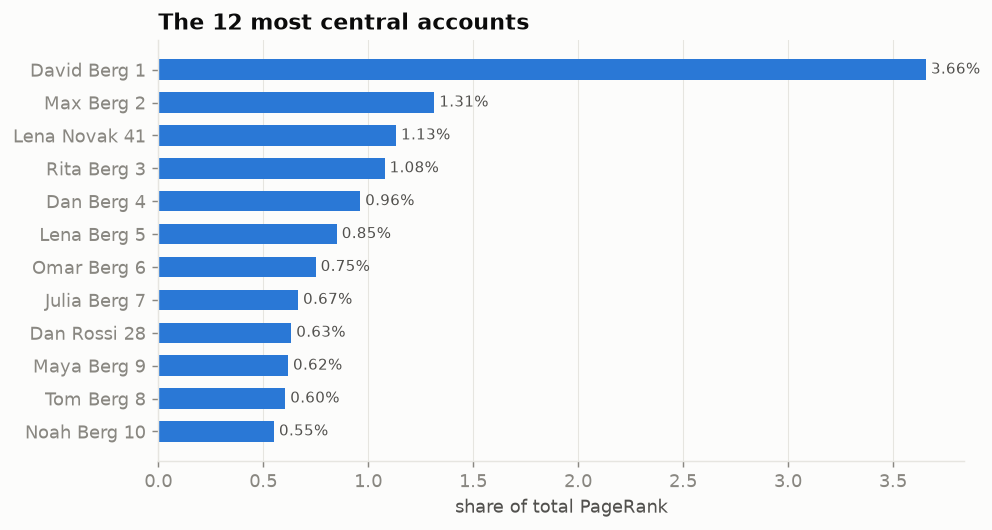

In [10]:
top = q(f'''
SELECT a.name, a.kind, a.city, r.rank
FROM (SELECT vgraph.gpagerank({COLS} USING PARAMETERS graph='nb', iterations=20, damping=0.85, top=12) OVER() FROM VGRAPH_NB.nb_delta) r
JOIN VGRAPH_NB.accounts a ON a.id = r.node ORDER BY r.rank DESC''')
print(f"all {N} accounts ranked, answered in {q.ms} ms (server time)")
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.name[::-1], top["rank"][::-1] * 100, color=BLUE, height=0.62)
for y, v in enumerate(top["rank"][::-1] * 100): ax.text(v, y, f" {v:.2f}%", va="center", fontsize=8.5, color=INK2)
ax.grid(axis="y", visible=False); ax.set_xlabel("share of total PageRank"); ax.set_title("The 12 most central accounts"); plt.show()

## 6. Graph features into in-database machine learning

This is where a graph inside an analytic database pays off. The output of the graph functions is a table,
so it can be stored next to the business data and handed to Vertica's machine learning, here through VerticaPy,
without moving a row out of the database.

Features per account: PageRank, the number of payers, the number of payees, money in, money out.
An isolation forest scores how unusual each account is.

In [11]:
run(f'''
DROP TABLE IF EXISTS VGRAPH_NB.features CASCADE;
CREATE TABLE VGRAPH_NB.features AS
SELECT a.id, a.name, a.kind, r.rank * 1e6 AS pagerank,
       NVL(i.payers, 0) AS payers, NVL(o.payees, 0) AS payees, NVL(i.money_in, 0) AS money_in, NVL(o.money_out, 0) AS money_out
FROM VGRAPH_NB.accounts a
JOIN (SELECT vgraph.gpagerank({COLS} USING PARAMETERS graph='nb') OVER() FROM VGRAPH_NB.nb_delta) r ON r.node = a.id
LEFT JOIN (SELECT dst, COUNT(DISTINCT src) AS payers, SUM(amount) AS money_in FROM VGRAPH_NB.transfers GROUP BY dst) i ON i.dst = a.id
LEFT JOIN (SELECT src, COUNT(DISTINCT dst) AS payees, SUM(amount) AS money_out FROM VGRAPH_NB.transfers GROUP BY src) o ON o.src = a.id
''')
from verticapy.machine_learning.vertica import IsolationForest
model = IsolationForest("VGRAPH_NB.nb_iforest", n_estimators=100, max_depth=8, overwrite_model=True)
model.fit("VGRAPH_NB.features", ["pagerank", "payers", "payees", "money_in", "money_out"])
scored = model.decision_function("VGRAPH_NB.features", name="unusual")
unusual = scored.sort({"unusual": "desc"}).head(12).to_pandas()
unusual[["name", "kind", "pagerank", "payers", "payees", "money_in", "money_out", "unusual"]]



call_string
SELECT iforest('VGRAPH_NB.nb_iforest', 'VGRAPH_NB.features', '"pagerank", "payers", "payees", "money_in", "money_out"' USING PARAMETERS exclude_columns='', ntree=100, sampling_size=0.632, col_sample_by_tree=1, max_depth=8, nbins=32);

details
predictor|      type      
---------+----------------
pagerank |float or numeric
 payers  |      int       
 payees  |      int       
money_in |float or numeric
money_out|float or numeric


Additional Info
       Name       |Value
------------------+-----
    tree_count    | 100 
rejected_row_count|  0  
accepted_row_count|50000



,name,kind,pagerank,payers,payees,money_in,money_out,unusual
0,David Berg 1,merchant,36571.967213,8033,0,836704.67,0.00,0.897407
1,Lena Novak 41,person,11326.562218,2739,3,1305752.69,801.69,0.880532
2,Max Berg 2,merchant,13146.686033,3249,0,334586.75,0.00,0.841330
3,Rita Berg 3,merchant,10780.098992,2600,0,270748.42,0.00,0.820325
4,Dan Berg 4,merchant,9618.845765,2221,0,235636.99,0.00,0.807029
5,Omar Novak 42,person,3000.998779,720,3,323137.66,1228.90,0.797946
6,Lena Berg 5,merchant,8502.109070,1782,0,189063.03,0.00,0.796522
7,Omar Berg 6,merchant,7498.271869,1630,0,169784.63,0.00,0.788535
8,Julia Berg 7,merchant,6659.076899,1587,0,168554.73,0.00,0.783134
9,Julia Novak 43,person,2332.291695,492,3,231458.16,703.87,0.773506


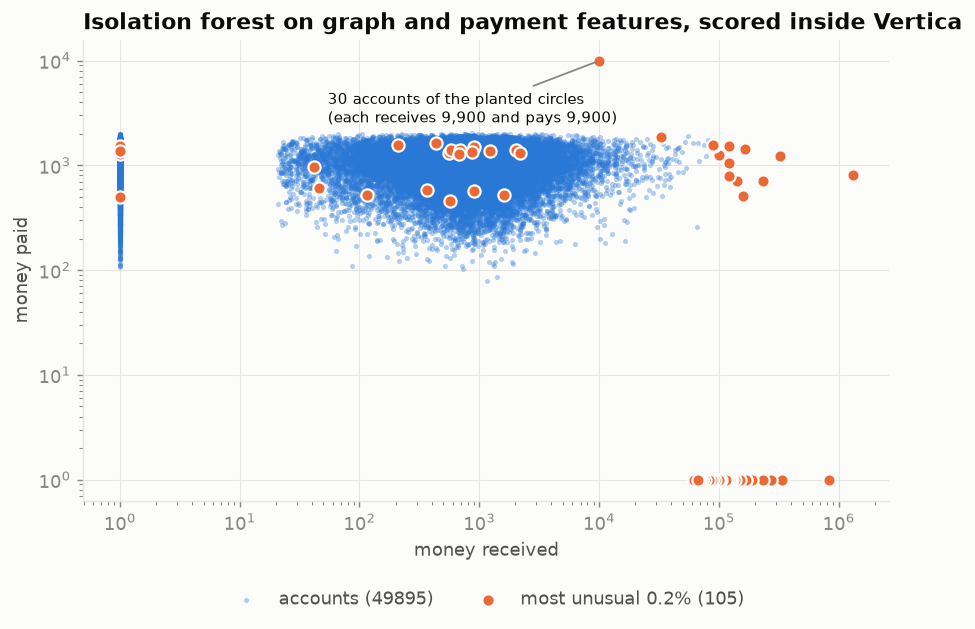

In [12]:
pts = scored.to_pandas()
cut = pts.unusual.quantile(0.998)
fig, ax = plt.subplots(figsize=(8, 4.6))
calm, odd = pts[pts.unusual < cut], pts[pts.unusual >= cut]
ax.scatter(calm.money_in + 1, calm.money_out + 1, s=8, color=BLUE, alpha=0.35, linewidths=0, label=f"accounts ({len(calm)})")
ax.scatter(odd.money_in + 1, odd.money_out + 1, s=46, color=ORANGE, edgecolors=SURFACE, linewidths=1.2, label=f"most unusual 0.2% ({len(odd)})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("money received"); ax.set_ylabel("money paid")
ring = odd[(odd.money_in == 9900) & (odd.money_out == 9900)]
if len(ring): ax.annotate(f"{len(ring)} accounts of the planted circles\n(each receives 9,900 and pays 9,900)", (9900, 9900), xytext=(-150, -34),
                          textcoords="offset points", fontsize=8.5, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.legend(frameon=False, labelcolor=INK2, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
ax.set_title("Isolation forest on graph and payment features, scored inside Vertica"); plt.show()

## 7. A transfer arrives: the answers change, nothing is rebuilt

An external graph database is as fresh as its last import. Here the edge table *is* the source. A query
reads the snapshot and the journal rows written after it, so a transfer committed a moment ago is already
part of the answer. Below, the flagged account pays a member of the 15-account circle. No refresh is called.

before: 78 accounts, now: 83, without a refresh. New on the money trail:
 node  hops               name
49986     1  Omar Keller 49986
49987     2 Julia Keller 49987
49988     3   Tom Keller 49988
49989     4  Maya Keller 49989
49990     5  Noah Keller 49990


closed circles left: 2 (the third one is now connected to everyone else)


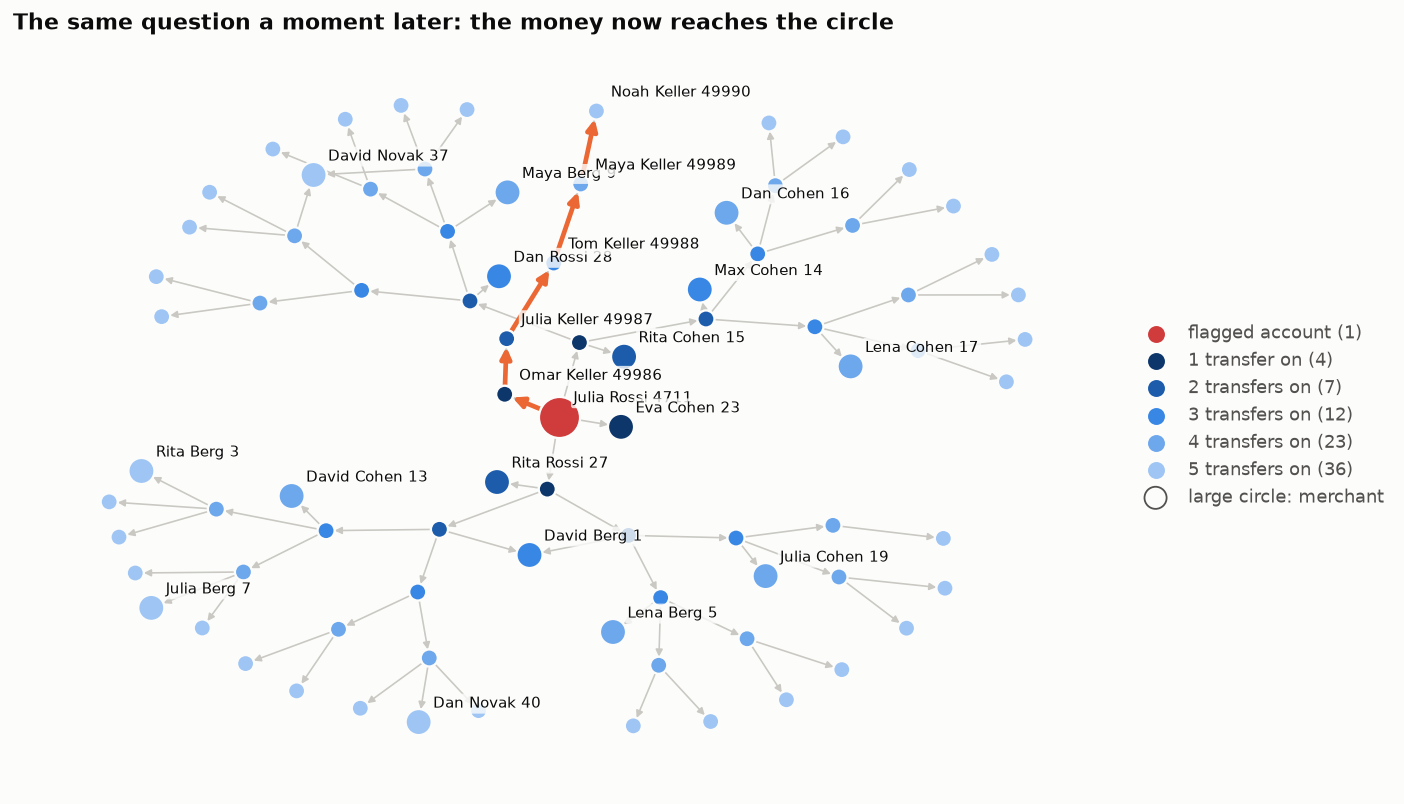

In [13]:
before = len(hood)
run(f"INSERT INTO VGRAPH_NB.transfers (src, dst, amount) VALUES ({FLAGGED}, {N} - 14, 9900);\nCOMMIT")
hood2 = q(f'''
SELECT r.node, r.hops, a.name, a.city, a.kind
FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={FLAGGED}, depth={DEPTH}, direction='out') OVER()
      FROM VGRAPH_NB.nb_delta) r JOIN VGRAPH_NB.accounts a ON a.id = r.node''')
new = hood2[~hood2.node.isin(hood.node)]
print(f"before: {before} accounts, now: {len(hood2)}, without a refresh. New on the money trail:")
print(new[["node", "hops", "name"]].to_string(index=False))
small = q(f'''SELECT COUNT(*) AS closed_circles FROM (SELECT vgraph.gcomponents_count({COLS} USING PARAMETERS graph='nb') OVER()
             FROM VGRAPH_NB.nb_delta) c WHERE nodes < 100''')
print(f"closed circles left: {small.closed_circles[0]} (the third one is now connected to everyone else)")
draw_hood(hood2, "The same question a moment later: the money now reaches the circle", new=set(new.node))

A reversal is one more row, with `del = true`, and it is seen just as quickly. `vgraph.status` tells how many
changes are waiting for the next scheduled rebuild (`vgraph.schedule_refresh('nb', '0 * * * *')`).

In [14]:
run(f"INSERT INTO VGRAPH_NB.transfers (src, dst, del) VALUES ({FLAGGED}, {N} - 14, TRUE);\nCOMMIT")
n = q(f'''SELECT COUNT(*) AS n FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={FLAGGED}, depth={DEPTH}, direction='out') OVER()
          FROM VGRAPH_NB.nb_delta) r''').n[0]
print(f"after the reversal: {n} accounts again")

after the reversal: 78 accounts again


## 8. How far does this go? One billion edges

The same function on a contact table of **1,000,000,000 rows** (166.7 million people, graph `big`,
built by the repository's benchmark on a single node). Skip this cell if that graph is not on your system.
`gkhop_count` returns one row per distance, so nothing large travels to the client.

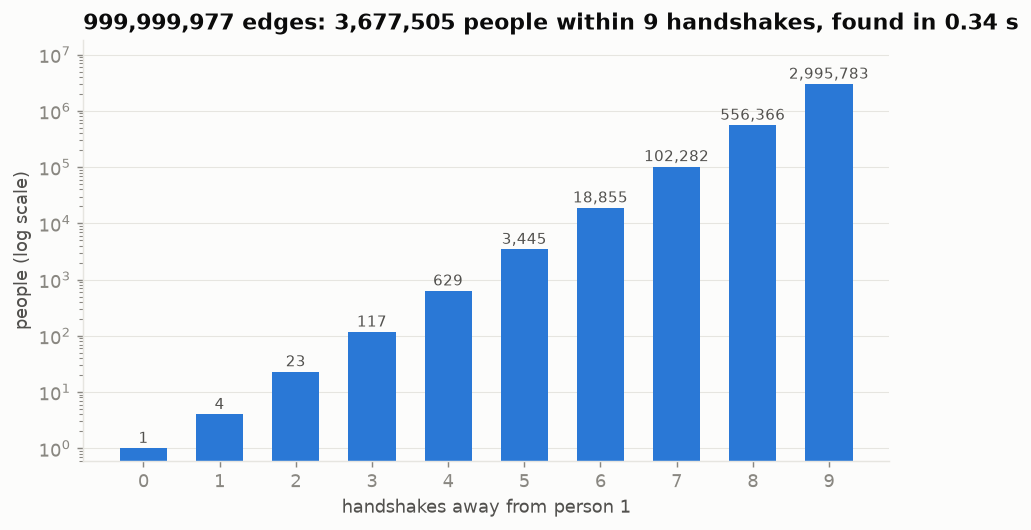

In [15]:
BIG = "big"
if q(f"SELECT COUNT(*) AS n FROM vgraph.manifest WHERE graph = '{BIG}' AND active_snapshot IS NOT NULL").n[0] == 0:
    print(f"graph '{BIG}' is not registered here: skipped")
else:
    info = q(f"SELECT node_count, edge_count FROM vgraph.manifest WHERE graph = '{BIG}'")
    levels = q(f'''SELECT hops, nodes FROM (SELECT vgraph.gkhop_count(1, NULL::INT, NULL::INT, NULL::INT, NULL::BOOLEAN, NULL::FLOAT, NULL::INT, NULL::INT
                   USING PARAMETERS graph='{BIG}', depth=9) OVER() FROM dual) r ORDER BY hops''')
    secs = q.ms / 1000
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.bar(levels.hops, levels.nodes, color=BLUE, width=0.62)
    for x, v in zip(levels.hops, levels.nodes): ax.text(x, v * 1.25, f"{v:,}", ha="center", fontsize=8.5, color=INK2)
    ax.set_yscale("log"); ax.set_ylim(0.6, levels.nodes.max() * 6); ax.grid(axis="x", visible=False)
    ax.set_xticks(levels.hops); ax.set_xlabel("handshakes away from person 1"); ax.set_ylabel("people (log scale)")
    ax.set_title(f"{info.edge_count[0]:,} edges: {levels.nodes.sum():,} people within 9 handshakes, found in {secs:.2f} s"); plt.show()

## 9. Measurements

Server times from `v_monitor.query_requests`, results counted inside the database. The numbers are those of the
repository's README (`scripts/benchmark.sh` and `scripts/neo4j_compare.sh` reproduce them). Edit the dictionaries
below with the numbers of your own run.

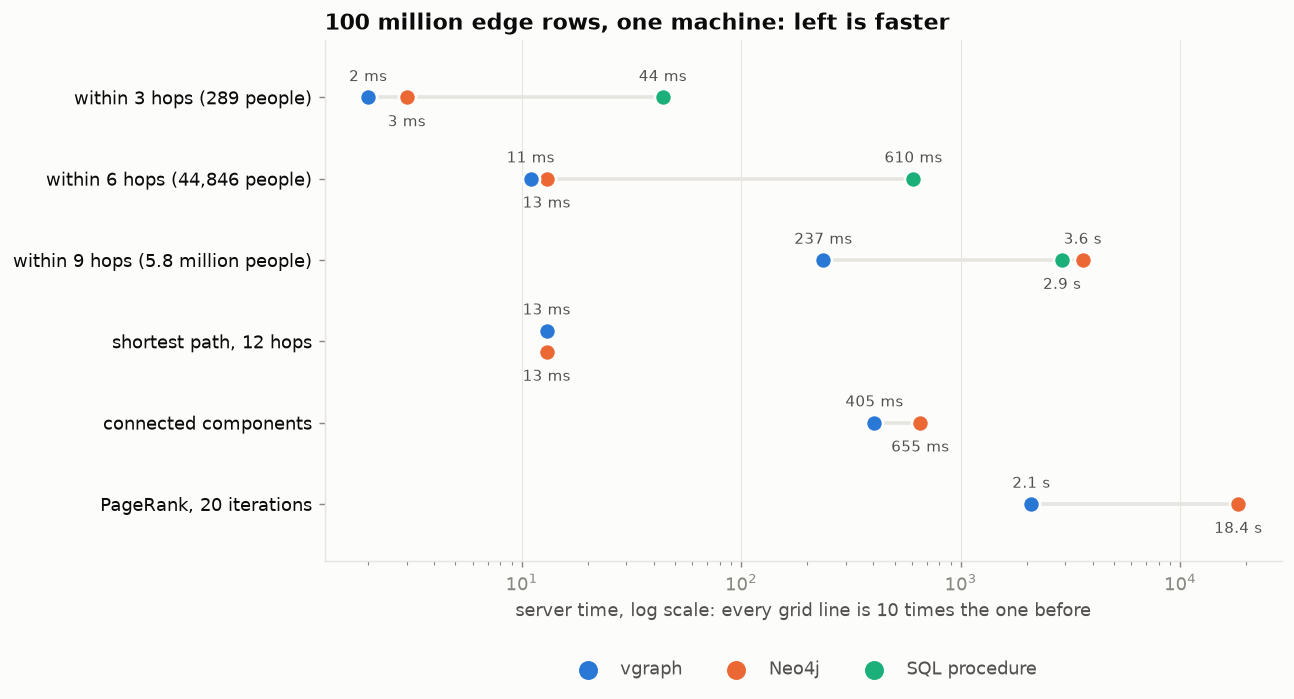

vgraph unfenced. Neo4j: the better of APOC and a Cypher pattern; components and PageRank need a 5.6 s projection first, not included.
SQL procedure: the level-by-level BFS of github.com/mogomo/vertica-graphs-and-trees, a separate run of the same generator.


In [16]:
# milliseconds. 100M: one node, 8 cores (ARM), both systems on the same machine and the same data.
M100 = {
    "within 3 hops (289 people)":         {"vgraph": 2,    "Neo4j": 3,     "SQL procedure": 44},
    "within 6 hops (44,846 people)":      {"vgraph": 11,   "Neo4j": 13,    "SQL procedure": 610},
    "within 9 hops (5.8 million people)": {"vgraph": 237,  "Neo4j": 3600,  "SQL procedure": 2900},
    "shortest path, 12 hops":             {"vgraph": 13,   "Neo4j": 13},
    "connected components":               {"vgraph": 405,  "Neo4j": 655},
    "PageRank, 20 iterations":            {"vgraph": 2100, "Neo4j": 18400},
}
B1 = {
    "within 2 hops (41 people)":             {"vgraph": 3},
    "within 9 hops (3.7 million people)":    {"vgraph": 350, "SQL procedure": 16800},
    "shortest path, 11 hops":                {"vgraph": 34},
    "connected components":                  {"vgraph": 5200},
    "PageRank, 20 iterations":               {"vgraph": 24900},
    "within 12 hops (159.6 million people)": {"vgraph": 15400},
}
COLOR = {"vgraph": BLUE, "Neo4j": ORANGE, "SQL procedure": AQUA}

def human(ms): return f"{ms / 1000:.1f} s" if ms >= 1000 else f"{ms:.0f} ms"

def dots(ax, data, title):
    rows = list(data)[::-1]
    for y, name in enumerate(rows):
        vals = data[name]
        ax.plot([min(vals.values()), max(vals.values())], [y, y], color=GRID, lw=2, zorder=1)
        for k, (system, ms) in enumerate(sorted(vals.items(), key=lambda kv: kv[1])):
            tie = sum(1 for other in vals.values() if other == ms) > 1              # equal times: show both dots
            dy = {"vgraph": 0.13, "Neo4j": -0.13}.get(system, 0) if tie else 0
            ax.scatter(ms, y + dy, s=90, color=COLOR[system], edgecolors=SURFACE, linewidths=1.5, zorder=3 if system == "vgraph" else 2)
            ax.annotate(human(ms), (ms, y + dy), xytext=(0, 9 if (dy > 0 or (not tie and k % 2 == 0)) else -16), textcoords="offset points",
                        ha="center", fontsize=8.5, color=INK2)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, color=INK); ax.set_ylim(-0.7, len(rows) - 0.3)
    ax.set_xscale("log"); ax.grid(axis="y", visible=False); ax.set_xlabel("server time, log scale: every grid line is 10 times the one before")
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
dots(ax, M100, "100 million edge rows, one machine: left is faster")
for system, c in COLOR.items(): ax.scatter([], [], s=90, color=c, label=system)
ax.legend(frameon=False, labelcolor=INK2, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3); plt.show()
print("vgraph unfenced. Neo4j: the better of APOC and a Cypher pattern; components and PageRank need a 5.6 s projection first, not included.")
print("SQL procedure: the level-by-level BFS of github.com/mogomo/vertica-graphs-and-trees, a separate run of the same generator.")

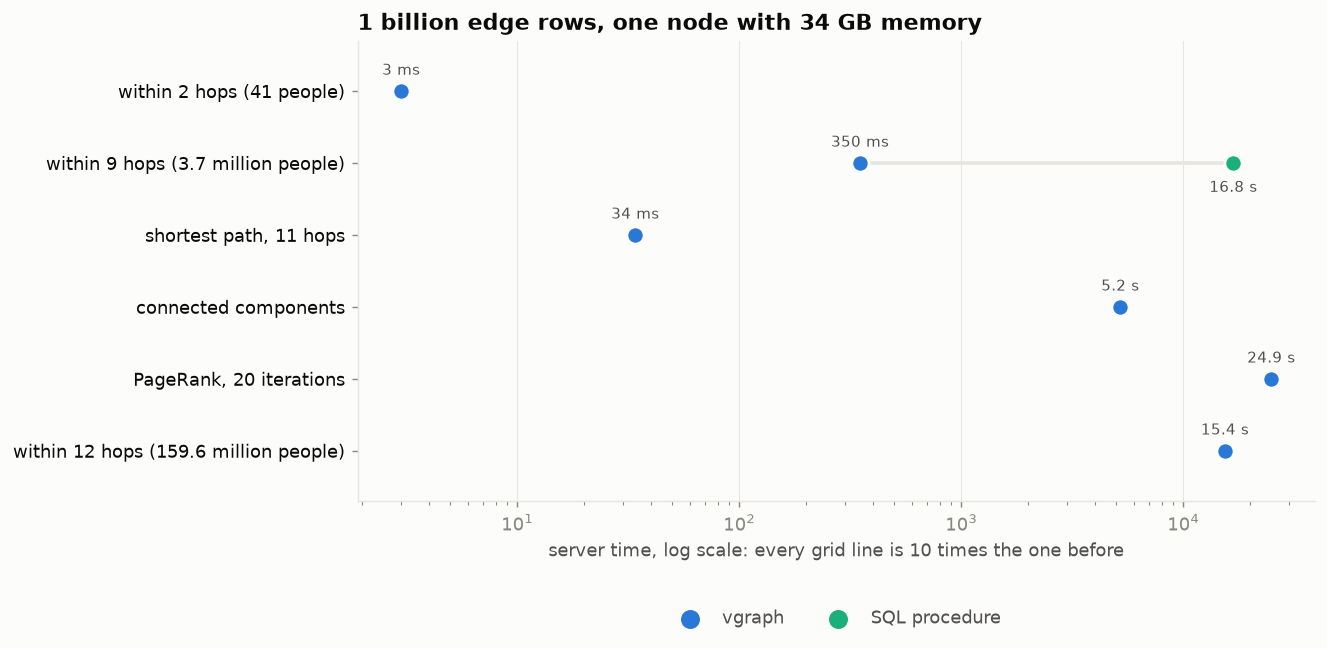

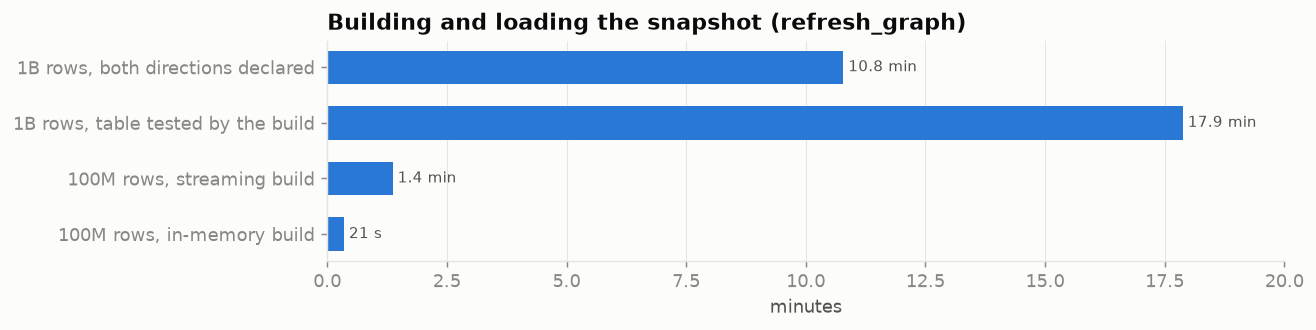

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
dots(ax, B1, "1 billion edge rows, one node with 34 GB memory")
for system in ("vgraph", "SQL procedure"): ax.scatter([], [], s=90, color=COLOR[system], label=system)
ax.legend(frameon=False, labelcolor=INK2, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2); plt.show()

fig, ax = plt.subplots(figsize=(9.5, 2.2))
steps = ["1B rows, both directions declared", "1B rows, table tested by the build", "100M rows, streaming build", "100M rows, in-memory build"]
mins = [647 / 60, 1072.7 / 60, 82 / 60, 21 / 60]
ax.barh(steps[::-1], mins[::-1], color=BLUE, height=0.6)
for y, v in enumerate(mins[::-1]): ax.text(v, y, f" {v:.1f} min" if v >= 1 else f" {v * 60:.0f} s", va="center", fontsize=8.5, color=INK2)
ax.grid(axis="y", visible=False); ax.set_xlabel("minutes"); ax.set_xlim(0, 20); ax.set_title("Building and loading the snapshot (refresh_graph)"); plt.show()

## Clean up

    CALL vgraph.unregister_graph('nb');
    DROP SCHEMA VGRAPH_NB CASCADE;